In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import scipy
import japanize_matplotlib

## 心電図データの読み込み

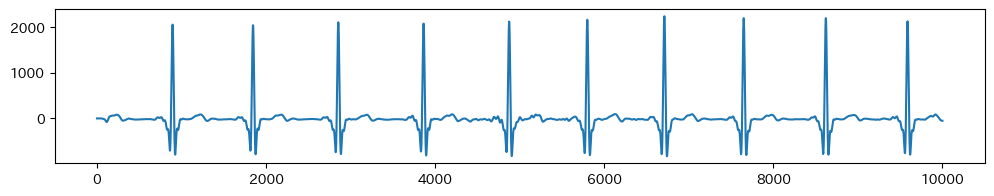

In [2]:
# 全データの読み込み
ecg = pd.read_csv('ECG.csv', header=None)

# 最初の1万行のデータの抽出
tmp_ecg = ecg.loc[:10_000,:]

# 心電図の描画
plt.figure(figsize=(12,2))
plt.plot(tmp_ecg)

## HRV.csvの読み込み

In [3]:
hrv = pd.read_csv('HRV.csv')
hrv

,elapsedTime,rri,meanNN,SDNN,TotalPower,RMSSD,NN50,LF,HF,LFHF,LFnu,HFnu
0,951,951,951.000000,0.000000,0.000000,NaN,0,0.000000,0.000000,0.000000,NaN,NaN
1,1960,1009,980.000000,29.000000,841.000000,58.000000,1,0.000000,0.000000,0.000000,NaN,NaN
2,2969,1009,989.666667,27.341462,747.555556,41.012193,1,0.000000,0.000000,0.000000,NaN,NaN
3,3981,1012,995.250000,25.577089,654.187500,33.531080,1,0.000000,0.000000,0.000000,NaN,NaN
4,4905,924,981.000000,36.545862,1335.600000,52.718593,2,0.000000,0.000000,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
60125,55546602,950,932.041237,32.091177,1029.843660,28.207503,14,267.599559,239.263299,1.118431,0.527953,0.472047
60126,55547521,919,931.814433,32.026996,1025.728451,28.242840,14,267.702423,237.344746,1.127905,0.530054,0.469946
60127,55548470,949,931.865979,32.046560,1026.982038,28.131077,14,266.927223,238.540962,1.119000,0.528079,0.471921
60128,55549419,949,931.680412,31.841925,1013.908173,28.063861,14,264.815153,241.855797,1.094930,0.522657,0.477343


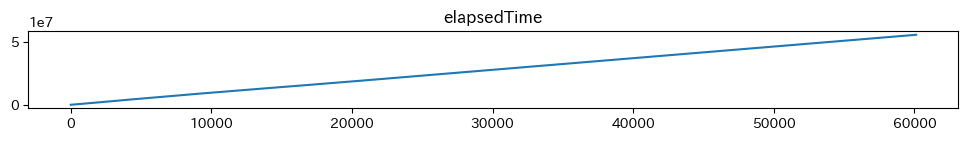

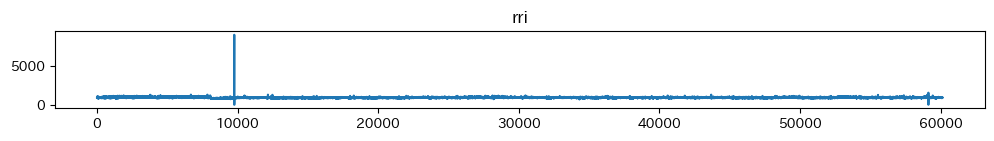

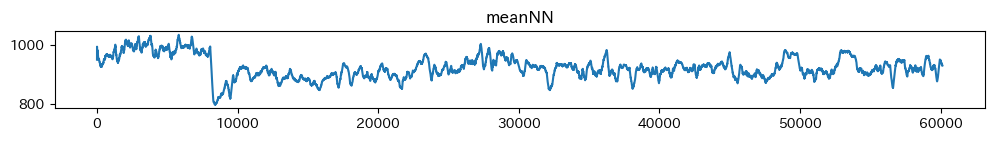

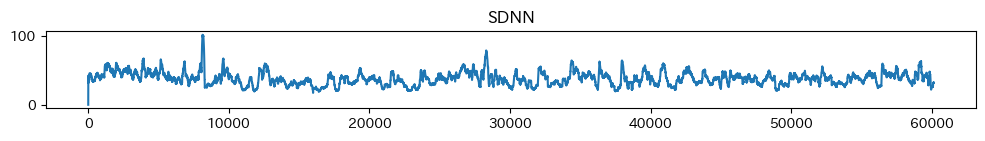

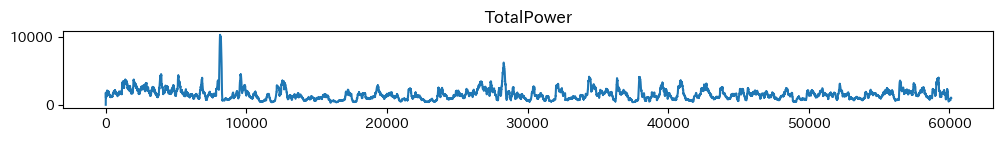

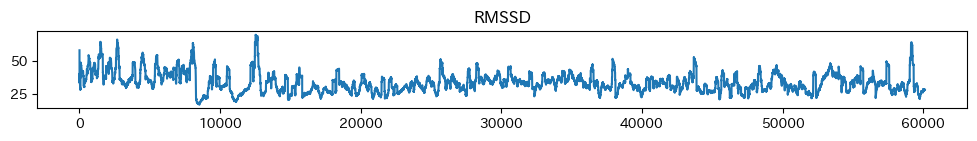

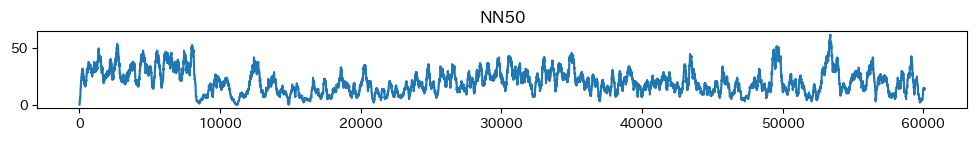

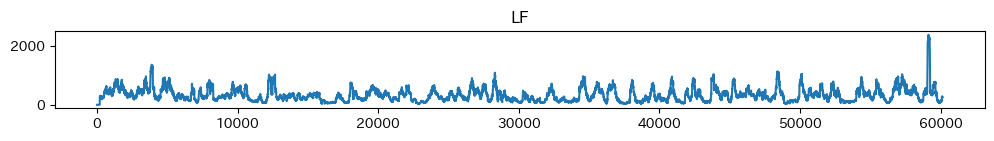

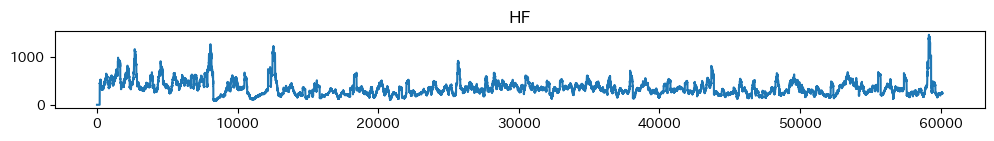

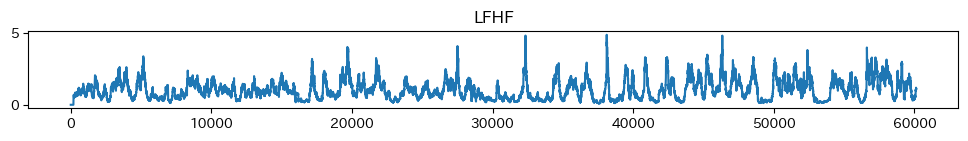

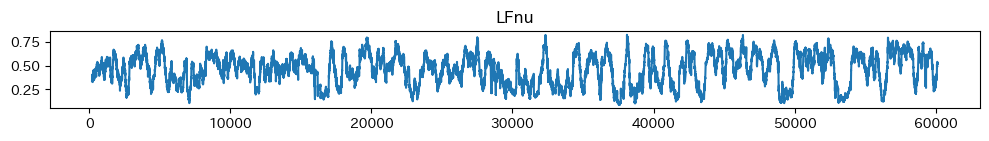

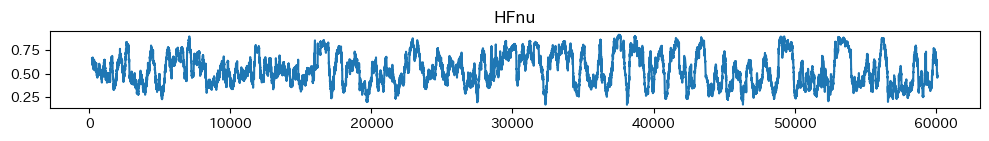

In [4]:
for i in hrv.columns:
    plt.figure(figsize=(12,1))
    plt.title(i)
    plt.plot(hrv[i])
    plt.show()

## RRI.csvの読み込み

In [5]:
rri = pd.read_csv('RRI.csv')
rri

,elapsedTime,rri
0,1.845,951
1,2.854,1009
2,3.863,1009
3,4.875,1012
4,5.799,924
...,...,...
60763,55996.173,950
60764,55997.092,919
60765,55998.041,949
60766,55998.990,949


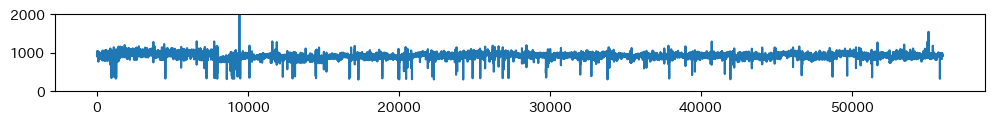

In [6]:
plt.figure(figsize=(12,1))
plt.plot(rri['elapsedTime'], rri['rri'])
plt.ylim(0,2000)
plt.show()

In [7]:
nn = rri['rri']/1000
nn

0        0.951
1        1.009
2        1.009
3        1.012
4        0.924
         ...  
60763    0.950
60764    0.919
60765    0.949
60766    0.949
60767    0.917
Name: rri, Length: 60768, dtype: float64

In [8]:
from scipy.signal import welch
import numpy as np

# nn: NN間隔（秒）, fs: 補間後サンプリング周波数
f, psd = welch(nn, fs=4.0)

lf = np.trapz(psd[(f>=0.04)&(f<0.15)], f[(f>=0.04)&(f<0.15)])
hf = np.trapz(psd[(f>=0.15)&(f<0.40)], f[(f>=0.15)&(f<0.40)])

lf_hf = lf / hf


/var/folders/00/yvsxrd0539vbhp0zd3gnv7tc0000gn/T/ipykernel_44317/3523296131.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(psd[(f>=0.04)&(f<0.15)], f[(f>=0.04)&(f<0.15)])
/var/folders/00/yvsxrd0539vbhp0zd3gnv7tc0000gn/T/ipykernel_44317/3523296131.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(psd[(f>=0.15)&(f<0.40)], f[(f>=0.15)&(f<0.40)])


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ---------------------------------
# Welch法でPSD計算
# ---------------------------------
fs = 1
f, psd = welch(nn, fs=fs, nperseg=256)

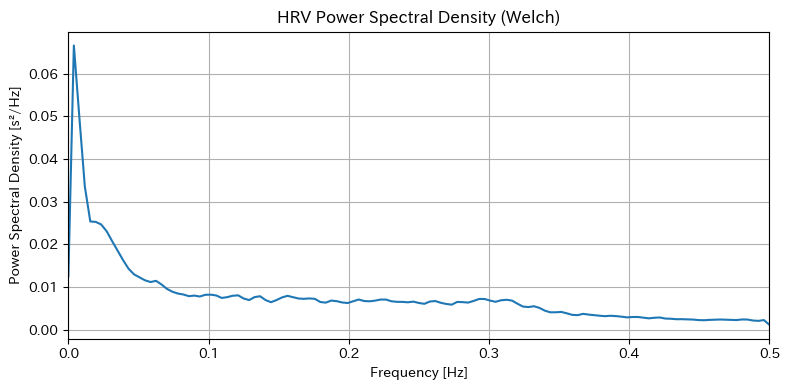

In [10]:
# ---------------------------------
# PSDプロット
# ---------------------------------
plt.figure(figsize=(8, 4))
plt.plot(f, psd)
plt.xlim(0, 0.5)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power Spectral Density [s²/Hz]")
plt.title("HRV Power Spectral Density (Welch)")
plt.grid(True)
plt.tight_layout()
plt.show()

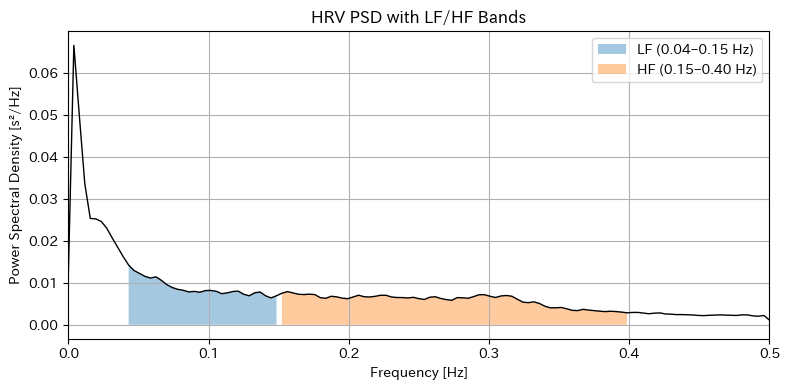

In [11]:
plt.figure(figsize=(8, 4))

plt.plot(f, psd, color="black", lw=1)

# LF帯
lf_mask = (f >= 0.04) & (f < 0.15)
plt.fill_between(f[lf_mask], psd[lf_mask],
                 alpha=0.4, label="LF (0.04–0.15 Hz)")

# HF帯
hf_mask = (f >= 0.15) & (f < 0.40)
plt.fill_between(f[hf_mask], psd[hf_mask],
                 alpha=0.4, label="HF (0.15–0.40 Hz)")

plt.xlim(0, 0.5)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power Spectral Density [s²/Hz]")
plt.title("HRV PSD with LF/HF Bands")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.signal import welch

def plot_psd_welch_from_rri(rri, fs_resample=4.0, nperseg=256, detrend='constant'):
    """
    rri: array-like or pd.Series of RR intervals in seconds (e.g., 0.95, 1.01, ...)
    fs_resample: resampling frequency [Hz] for interpolated HR time series (common: 4 Hz)
    nperseg: segment length for Welch
    detrend: detrend option for welch
    """
    # ---- 0) sanitize ----
    rri = np.asarray(rri, dtype=float)
    rri = rri[np.isfinite(rri)]
    rri = rri[(rri > 0.2) & (rri < 3.0)]  # ざっくり外れ値除去（必要に応じて調整）

    if len(rri) < 10:
        raise ValueError("RRIが短すぎます（最低でも数十点は欲しいです）。")

    # ---- 1) RRI -> 心拍時刻（Rピーク時刻）を復元（累積和）----
    t_beats = np.cumsum(rri)  # 秒
    t_beats = t_beats - t_beats[0]  # 0始まりに

    # ---- 2) 瞬時心拍（HR）系列へ（HzでもbpmでもOK。ここではHz）----
    # beat-to-beatのHRは区間に対応するので、時刻を区間中央に置くのが扱いやすい
    t_mid = (t_beats[:-1] + t_beats[1:]) / 2.0
    hr_hz = 1.0 / rri[1:]  # Hz（bpmにするなら *60）

    # ---- 3) 等間隔グリッドへ補間（Welch用）----
    t_uniform = np.arange(t_mid[0], t_mid[-1], 1.0 / fs_resample)

    # 線形補間（好みで 'cubic' も可。ただし暴れやすいことあり）
    f_interp = interpolate.interp1d(t_mid, hr_hz, kind='linear', fill_value='extrapolate')
    hr_uniform = f_interp(t_uniform)

    # ---- 4) Welch法でPSD ----
    f, pxx = welch(
        hr_uniform,
        fs=fs_resample,
        window='hann',
        nperseg=min(nperseg, len(hr_uniform)),
        noverlap=None,         # デフォルトで nperseg//2
        detrend=detrend,
        scaling='density'
    )

    # ---- 5) 図 ----
    plt.figure(figsize=(8, 4.5))
    plt.plot(f, pxx)  # PSDはlog表示が見やすいことが多い
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD [Hz^2/Hz] (HR in Hz)")
    plt.title("PSD by Welch (Interpolated HR from RRI)")
    plt.grid(True)
    plt.xlim(0, 0.5)  # HRVを見るなら 0.5Hzくらいまでで十分なことが多い

    # HRVの帯域（VLF/LF/HF）を目印で
    for x in [0.04, 0.15, 0.40]:
        plt.axvline(x, linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

    return f, pxx

# ===== 使い方例 =====
# rri_series = あなたのRRI（秒）Series
# f, pxx = plot_psd_welch_from_rri(rri_series)


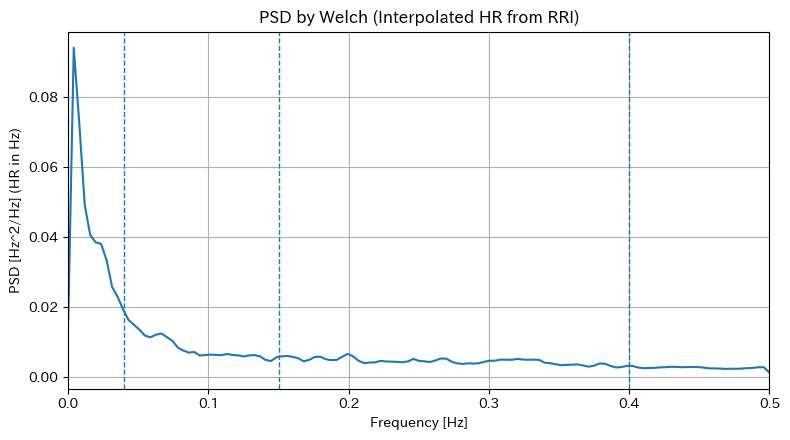

In [16]:
f, pxx = plot_psd_welch_from_rri(nn, fs_resample=1)